In [1]:
from google.colab import drive
drive.mount('/content/drive')

import torch
print(torch.cuda.is_available(), torch.cuda.get_device_name(0))

Mounted at /content/drive
True Tesla T4


In [2]:
%cd /content
!git clone https://github.com/graphdeco-inria/gaussian-splatting --recursive
%cd gaussian-splatting

/content
Cloning into 'gaussian-splatting'...
remote: Enumerating objects: 1053, done.
remote: Total 1053 (delta 0), reused 0 (delta 0), pack-reused 1053 (from 1)
Receiving objects: 100% (1053/1053), 78.72 MiB | 29.04 MiB/s, done.
Resolving deltas: 100% (593/593), done.
Submodule 'SIBR_viewers' (https://gitlab.inria.fr/sibr/sibr_core.git) registered for path 'SIBR_viewers'
Submodule 'submodules/diff-gaussian-rasterization' (https://github.com/graphdeco-inria/diff-gaussian-rasterization.git) registered for path 'submodules/diff-gaussian-rasterization'
Submodule 'submodules/fused-ssim' (https://github.com/rahul-goel/fused-ssim.git) registered for path 'submodules/fused-ssim'
Submodule 'submodules/simple-knn' (https://gitlab.inria.fr/bkerbl/simple-knn.git) registered for path 'submodules/simple-knn'
Cloning into '/content/gaussian-splatting/SIBR_viewers'...
remote: Enumerating objects: 3293, done.        
remote: Counting objects: 100% (322/322), done.        
remote: Compressing objects:

In [3]:
!pip install -q plyfile tqdm
!pip install -q submodules/diff-gaussian-rasterization
!pip install -q submodules/simple-knn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done


In [4]:
import os
import shutil

gs_data_path = '/content/drive/MyDrive/SpatialAI/outputs/reconstruction/desk_scene'
os.makedirs(os.path.join(gs_data_path, 'images'), exist_ok=True)
os.makedirs(os.path.join(gs_data_path, 'sparse'), exist_ok=True)

# Copy original images
source_images = '/content/drive/MyDrive/SpatialAI/data/raw_images'
for img_name in os.listdir(source_images):
    shutil.copy(
        os.path.join(source_images, img_name),
        os.path.join(gs_data_path, 'images', img_name)
    )

# Copy COLMAP's binary sparse reconstruction (not the text version — this pipeline wants binary)
source_sparse = '/content/drive/MyDrive/SpatialAI/outputs/camera_poses/sparse/0'
dest_sparse = os.path.join(gs_data_path, 'sparse', '0')
shutil.copytree(source_sparse, dest_sparse, dirs_exist_ok=True)

print("Data organized:")
print(f"Images: {len(os.listdir(os.path.join(gs_data_path, 'images')))}")
print(f"Sparse folder contents: {os.listdir(dest_sparse)}")

Data organized:
Images: 36
Sparse folder contents: ['cameras.bin', 'images.bin', 'points3D.bin', 'project.ini']


In [5]:
%cd /content/gaussian-splatting

!python train.py \
    -s {gs_data_path} \
    -m {gs_data_path}/output \
    --iterations 3000 \
    --test_iterations 3000 \
    --save_iterations 3000

/content/gaussian-splatting
2026-08-19 16:54:46.390631: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Optimizing /content/drive/MyDrive/SpatialAI/outputs/reconstruction/desk_scene/output
Output folder: /content/drive/MyDrive/SpatialAI/outputs/reconstruction/desk_scene/output [19/08 16:54:50]
Reading camera 1/36Traceback (most recent call last):
  File "/content/gaussian-splatting/train.py", line 282, in <module>
    training(lp.extract(args), op.extract(args), pp.extract(args), args.test_iterations, args.save_iterations, args.checkpoint_iterations, args.start_checkpoint, args.debug_from)
  File "/content/gaussian-splatting/train.py", line 51, in training
    scene = Scene(dataset, gaussians)
            ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/conten

In [7]:
#!apt-get update -q
#!apt-get install colmap -y -q



Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,578 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [110 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:9 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,908 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,314 kB]
Get:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-se

In [8]:
import os
os.environ['QT_QPA_PLATFORM'] = 'offscreen'

undistorted_path = os.path.join(gs_data_path, 'undistorted')
os.makedirs(undistorted_path, exist_ok=True)

!colmap image_undistorter \
    --image_path {os.path.join(gs_data_path, 'images')} \
    --input_path {os.path.join(gs_data_path, 'sparse', '0')} \
    --output_path {undistorted_path} \
    --output_type COLMAP


Reading reconstruction

 => Reconstruction with 36 images and 5234 points

Image undistortion

Undistorting image [1/36]
Undistorting image [2/36]
Undistorting image [3/36]
Undistorting image [4/36]
Undistorting image [5/36]
Undistorting image [6/36]
Undistorting image [7/36]
Undistorting image [8/36]
Undistorting image [9/36]
Undistorting image [10/36]
Undistorting image [11/36]
Undistorting image [12/36]
Undistorting image [13/36]
Undistorting image [14/36]
Undistorting image [15/36]
Undistorting image [16/36]
Undistorting image [17/36]
Undistorting image [18/36]
Undistorting image [19/36]
Undistorting image [20/36]
Undistorting image [21/36]
Undistorting image [22/36]
Undistorting image [23/36]
Undistorting image [24/36]
Undistorting image [25/36]
Undistorting image [26/36]
Undistorting image [27/36]
Undistorting image [28/36]
Undistorting image [29/36]
Undistorting image [30/36]
Undistorting image [31/36]
Undistorting image [32/36]
Undistorting image [33/36]
Undistorting image [34

In [9]:
print("Undistorted folder contents:")
for item in os.listdir(undistorted_path):
    print(f"  {item}")

sparse_undist = os.path.join(undistorted_path, 'sparse')
if os.path.exists(sparse_undist):
    print(f"\nSparse subfolder contents: {os.listdir(sparse_undist)}")

Undistorted folder contents:
  images
  sparse
  stereo
  run-colmap-photometric.sh
  run-colmap-geometric.sh

Sparse subfolder contents: ['cameras.bin', 'images.bin', 'points3D.bin']


In [10]:
import shutil

sparse_0_path = os.path.join(sparse_undist, '0')
os.makedirs(sparse_0_path, exist_ok=True)

for fname in ['cameras.bin', 'images.bin', 'points3D.bin']:
    src = os.path.join(sparse_undist, fname)
    dst = os.path.join(sparse_0_path, fname)
    if os.path.exists(src):
        shutil.move(src, dst)

print("Sparse folder contents now:", os.listdir(sparse_undist))
print("Sparse/0 folder contents:", os.listdir(sparse_0_path))

Sparse folder contents now: ['0']
Sparse/0 folder contents: ['cameras.bin', 'images.bin', 'points3D.bin']


In [11]:
%cd /content/gaussian-splatting

!python train.py \
    -s {undistorted_path} \
    -m {gs_data_path}/output \
    --iterations 3000 \
    --test_iterations 3000 \
    --save_iterations 3000

/content/gaussian-splatting
2026-08-19 17:06:26.334255: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Optimizing /content/drive/MyDrive/SpatialAI/outputs/reconstruction/desk_scene/output
Output folder: /content/drive/MyDrive/SpatialAI/outputs/reconstruction/desk_scene/output [19/08 17:06:31]
Reading camera 36/36 [19/08 17:06:31]
Converting point3d.bin to .ply, will happen only the first time you open the scene. [19/08 17:06:31]
Loading Training Cameras [19/08 17:06:31]
Loading Test Cameras [19/08 17:06:32]
Number of points at initialisation :  5234 [19/08 17:06:32]
Training progress: 100% 3000/3000 [01:29<00:00, 33.70it/s, Loss=0.0130128, Depth Loss=0.0000000]

[ITER 3000] Evaluating train: L1 0.008986864890903236 PSNR 37.332645416259766 [19/08

In [12]:
!python render.py \
    -s {undistorted_path} \
    -m {gs_data_path}/output \
    --iteration 3000

Looking for config file in /content/drive/MyDrive/SpatialAI/outputs/reconstruction/desk_scene/output/cfg_args
Config file found: /content/drive/MyDrive/SpatialAI/outputs/reconstruction/desk_scene/output/cfg_args
Rendering /content/drive/MyDrive/SpatialAI/outputs/reconstruction/desk_scene/output
Loading trained model at iteration 3000 [19/08 17:10:35]
Reading camera 36/36 [19/08 17:10:35]
Loading Training Cameras [19/08 17:10:35]
Loading Test Cameras [19/08 17:10:35]
Rendering progress: 100% 36/36 [00:11<00:00,  3.16it/s]
Rendering progress: 0it [00:00, ?it/s]


Found 36 rendered images


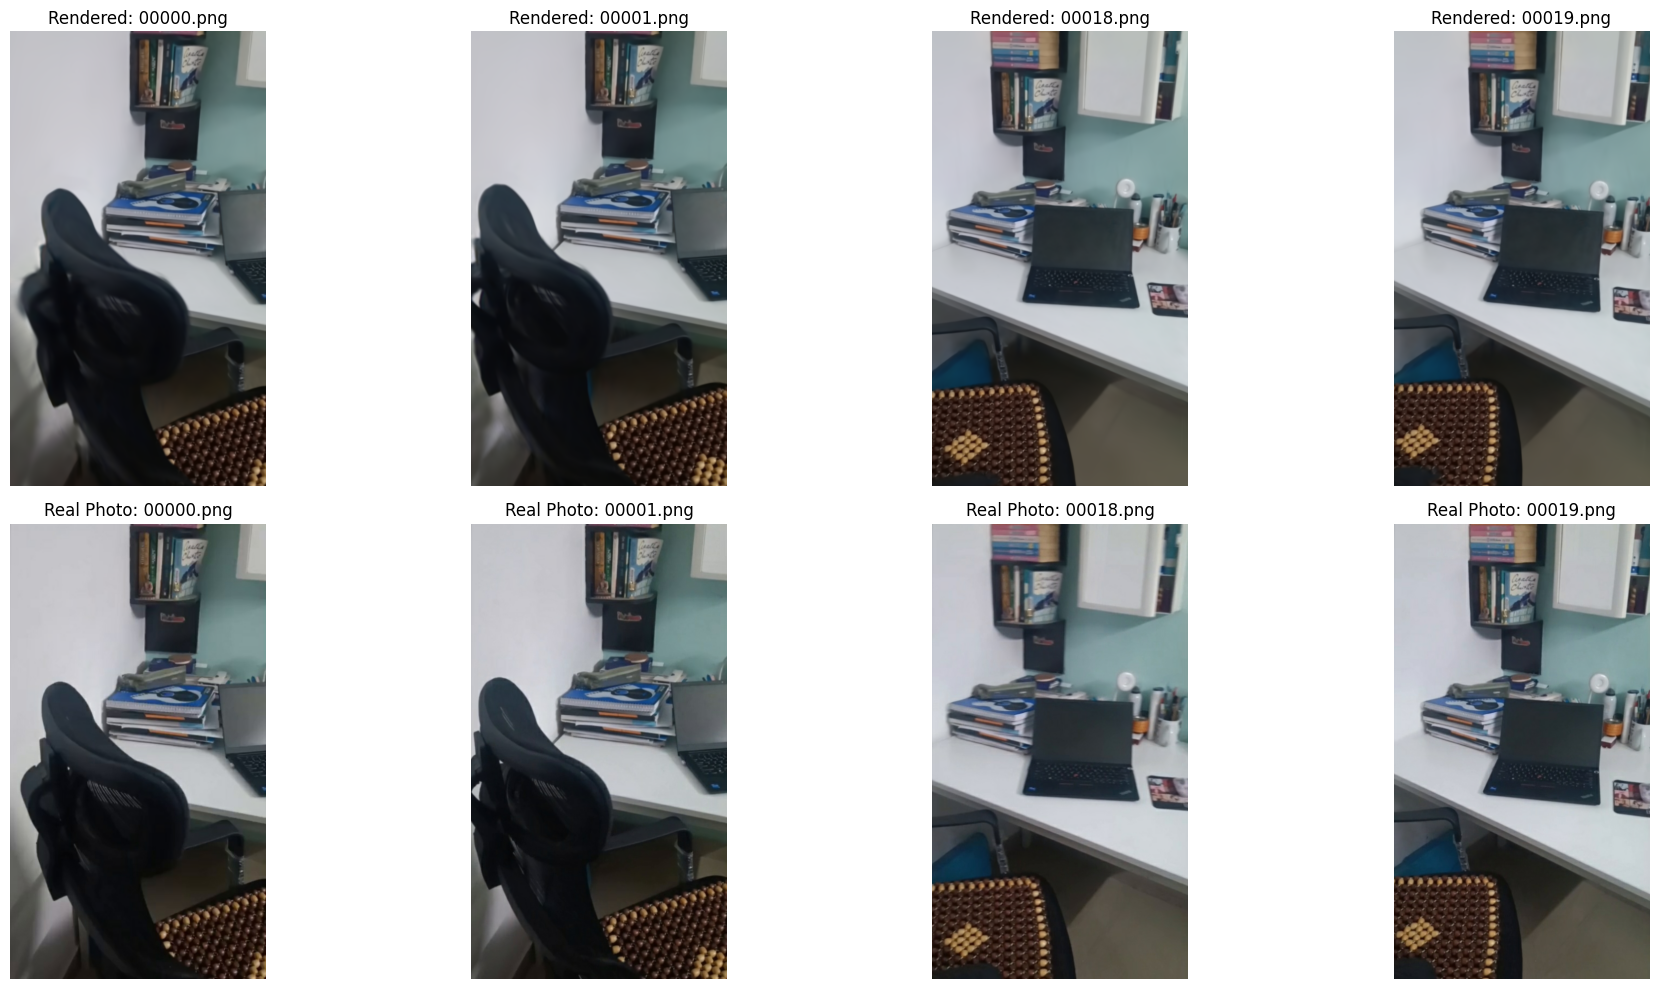

In [13]:
import matplotlib.pyplot as plt
from PIL import Image

render_dir = os.path.join(gs_data_path, 'output', 'train', 'ours_3000', 'renders')
gt_dir = os.path.join(gs_data_path, 'output', 'train', 'ours_3000', 'gt')

rendered_files = sorted(os.listdir(render_dir))
print(f"Found {len(rendered_files)} rendered images")

# Compare a few, side by side
sample_names = rendered_files[:2] + rendered_files[len(rendered_files)//2:len(rendered_files)//2+2]

fig, axes = plt.subplots(2, len(sample_names), figsize=(5*len(sample_names), 10))
for i, fname in enumerate(sample_names):
    rendered_img = Image.open(os.path.join(render_dir, fname))
    gt_img = Image.open(os.path.join(gt_dir, fname))

    axes[0, i].imshow(rendered_img)
    axes[0, i].set_title(f"Rendered: {fname}")
    axes[0, i].axis('off')

    axes[1, i].imshow(gt_img)
    axes[1, i].set_title(f"Real Photo: {fname}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [15]:
%cd /content/gaussian-splatting

!python train.py \
    -s {undistorted_path} \
    -m {gs_data_path}/output_full \
    --iterations 30000 \
    --test_iterations 7000 30000 \
    --save_iterations 7000 30000

/content/gaussian-splatting
2026-08-19 17:19:46.023814: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Optimizing /content/drive/MyDrive/SpatialAI/outputs/reconstruction/desk_scene/output_full
Output folder: /content/drive/MyDrive/SpatialAI/outputs/reconstruction/desk_scene/output_full [19/08 17:19:50]
Reading camera 36/36 [19/08 17:19:50]
Loading Training Cameras [19/08 17:19:50]
Loading Test Cameras [19/08 17:19:50]
Number of points at initialisation :  5234 [19/08 17:19:50]
Training progress:  23% 7000/30000 [04:16<17:33, 21.83it/s, Loss=0.0106517, Depth Loss=0.0000000]
[ITER 7000] Evaluating train: L1 0.008150940202176571 PSNR 37.98661651611328 [19/08 17:24:11]

[ITER 7000] Saving Gaussians [19/08 17:24:11]
Training progress: 100% 30000/3000

In [16]:
!python render.py \
    -s {undistorted_path} \
    -m {gs_data_path}/output_full \
    --iteration 30000

Looking for config file in /content/drive/MyDrive/SpatialAI/outputs/reconstruction/desk_scene/output_full/cfg_args
Config file found: /content/drive/MyDrive/SpatialAI/outputs/reconstruction/desk_scene/output_full/cfg_args
Rendering /content/drive/MyDrive/SpatialAI/outputs/reconstruction/desk_scene/output_full
Loading trained model at iteration 30000 [19/08 17:45:18]
Reading camera 36/36 [19/08 17:45:18]
Loading Training Cameras [19/08 17:45:18]
Loading Test Cameras [19/08 17:45:18]
Rendering progress: 100% 36/36 [00:11<00:00,  3.16it/s]
Rendering progress: 0it [00:00, ?it/s]


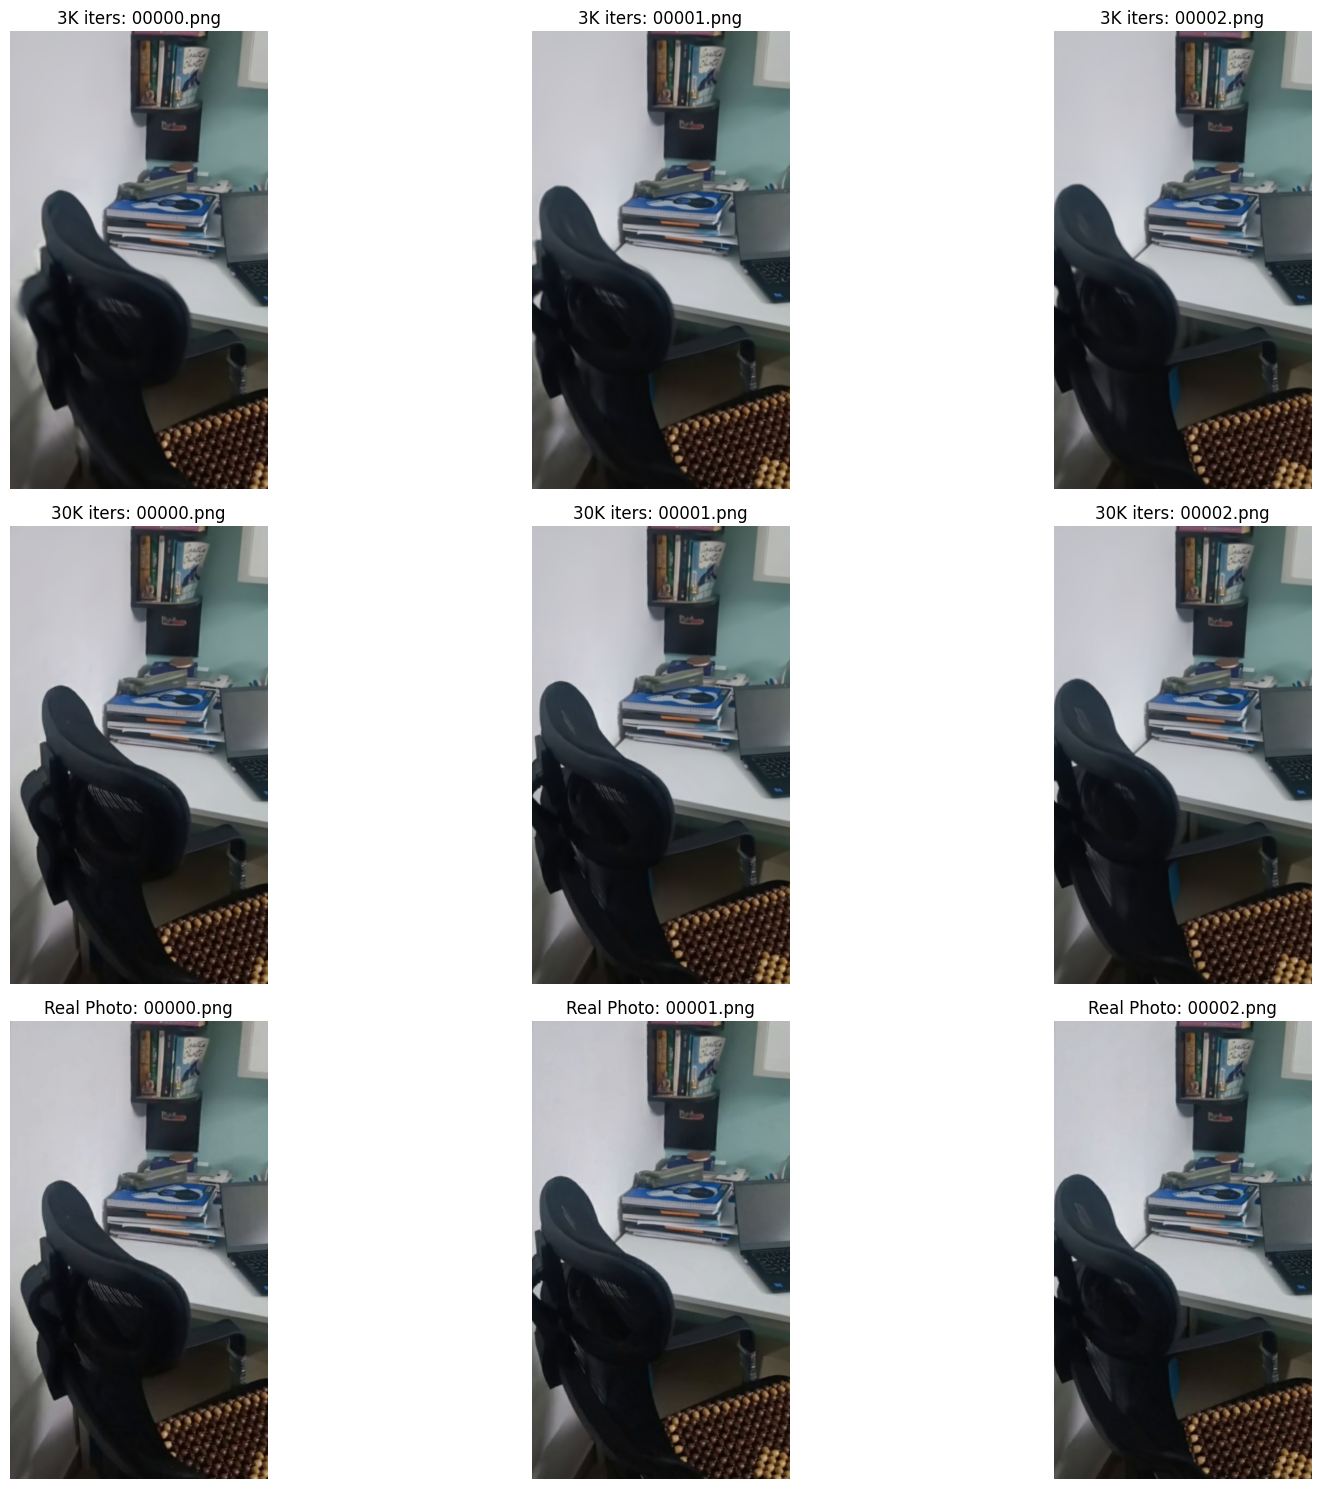

In [17]:
render_dir_3k = os.path.join(gs_data_path, 'output', 'train', 'ours_3000', 'renders')
render_dir_30k = os.path.join(gs_data_path, 'output_full', 'train', 'ours_30000', 'renders')
gt_dir_30k = os.path.join(gs_data_path, 'output_full', 'train', 'ours_30000', 'gt')

# Pick a frame that showed the chair (adjust index if needed based on what you saw earlier)
sample_files = sorted(os.listdir(render_dir_30k))[:3]

fig, axes = plt.subplots(3, len(sample_files), figsize=(6*len(sample_files), 15))
for i, fname in enumerate(sample_files):
    img_3k = Image.open(os.path.join(render_dir_3k, fname))
    img_30k = Image.open(os.path.join(render_dir_30k, fname))
    img_gt = Image.open(os.path.join(gt_dir_30k, fname))

    axes[0, i].imshow(img_3k)
    axes[0, i].set_title(f"3K iters: {fname}")
    axes[0, i].axis('off')

    axes[1, i].imshow(img_30k)
    axes[1, i].set_title(f"30K iters: {fname}")
    axes[1, i].axis('off')

    axes[2, i].imshow(img_gt)
    axes[2, i].set_title(f"Real Photo: {fname}")
    axes[2, i].axis('off')

plt.tight_layout()
plt.savefig('/content/comparison_3k_vs_30k.png', dpi=100)
plt.show()